# Derive kinetic conversion factors

In [19]:
import math
import pandas as pd
import numpy as np
import tellurium as te
import matplotlib.pyplot as plt

fn_ant = '../model/PBK_PFAS.ant'
param_files = {
    'PFOS': '../Parametrisations/PFOS_Human_Westerhout_2024.csv',
    'PFOA': '../Parametrisations/PFOA_Human_Westerhout_2024.csv'
}

doses = []
for i in range(-6, 1):
    for j in [1,2,5]:
        doses.append(j * 10**i)
doses.append(10**1)
bws = [50, 70, 90, 110]
selected_outputs = ["[AArt_Plas]", "[AVen_Plas]"]
days_of_exposure = 30 * 365


## Simulation functions

In [20]:
def loadParametrisation(model, filename):
    df = pd.read_csv(filename)
    df['Value'] = df['Value'].astype(float)
    for index, row in df.iterrows():
        model[str(row['Parameter'])] = row['Value']

def simulate(
    param_filename,
    daily_per_bw_intake,
    days_of_exposure,
    bw
):
    # Load the PBPK model from the SBML file
    rr_model = te.loada(fn_ant)

    # Specify the input
    input_id = 'AGut'

    # Make sure A_gut is not constant and does not have boundary conditions
    rr_model.setInitAmount(input_id, 0)
    rr_model.setConstant(input_id, False)
    rr_model.setBoundary(input_id, False)

    # Remove all events
    for event_id in rr_model.model.getEventIds():
        rr_model.removeEvent(event_id)

    num_days = days_of_exposure

    # Set chemical parameters
    loadParametrisation(rr_model, param_filename)

    # Set physiological parameters
    rr_model.BW = bw
    daily_dose = daily_per_bw_intake * bw  # in ug/day

    # Create a repeating daily oral dosing
    eid = f"oral_daily_exposure"
    rr_model.addEvent(eid, False, f"time % 1 == 0 && time < {days_of_exposure}", False)
    rr_model.addEventAssignment(eid, input_id, f"{input_id} + {daily_dose}", False)
    rr_model.regenerateModel(True, True)

    # Simulate the PBPK model
    results = rr_model.simulate(0, num_days, num_days + 1)
    return results

def run_simulations(param_file):
    simulation_results = {}
    for bw in bws:
        for dose in doses:
            res = simulate(
                param_filename = param_file,
                daily_per_bw_intake = dose,
                days_of_exposure = days_of_exposure,
                bw = bw
            )
            # Store results with config as key
            simulation_results[(bw, dose)] = res
    return simulation_results


## Run simulations

In [21]:
param_simulation_results = {}
for key, value in param_files.items():
    param_simulation_results[key] = run_simulations(value)


## Plot time series

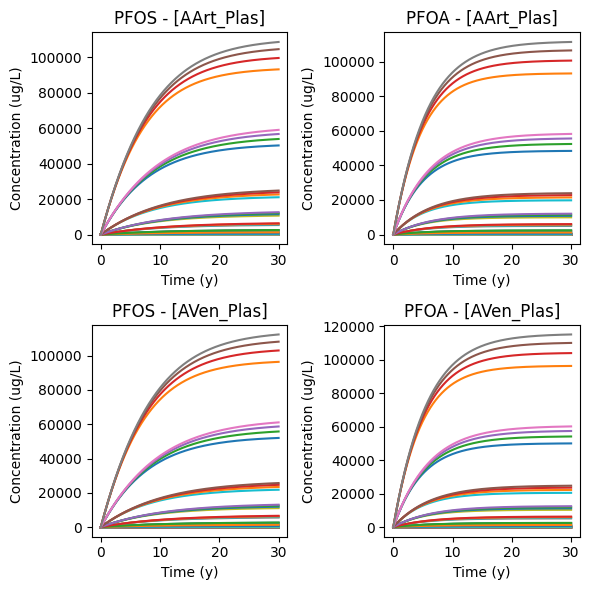

In [22]:
def plot_timeseries_all(param_simulation_results, selected_outputs):
    nplots = len(param_simulation_results) * len(selected_outputs)
    ncols = min(nplots, 2)
    nrows = max(math.ceil((nplots - 1) / ncols), 1)

    fig, axes = plt.subplots(nrows, ncols, figsize=(3*ncols, 3*nrows))
    axes = axes.flatten()

    for ax in axes:
        ax.set(xlabel='time') 

    i = 0
    for output in selected_outputs:
        for chem, simulation_results in param_simulation_results.items():
            axes[i].set(xlabel="Time (y)", ylabel=f"Concentration (ug/L)", title=f"{chem} - {output}")
            for (bw, dose), res in simulation_results.items():
                axes[i].plot(res['time'] / 365, res[output], label=f'bw={bw}, dose={dose}')
            i += 1

    for j in range(nplots, nrows * ncols):
        fig.delaxes(axes[j])

    pos = axes[0].get_position()
    axes[0].set_position([pos.x0, pos.y0, pos.width, pos.height * 0.85])
    fig.tight_layout()
    plt.show()

plot_timeseries_all(param_simulation_results, selected_outputs)


# Compute steady-state concentrations and kinetic conversion factor

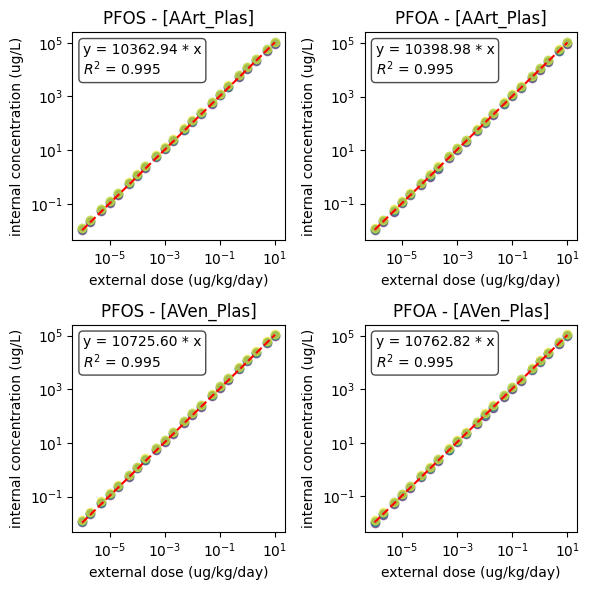

In [23]:
def compute_steady_state_concentrations(simulation_results, output):
    rows = []
    for bw in bws:
        for dose in doses:
            res = simulation_results[(bw, dose)]
            time = res['time']
            last_10_idx = time >= (time[-1] - 9)
            avg_ss = res[output][last_10_idx].mean()
            rows.append({
                'bw': bw,
                'dose': dose,
                'external dose': dose,
                'internal concentration': avg_ss
            })
    return pd.DataFrame(rows)

def plot_internal_vs_external(param_simulation_results, selected_outputs, as_ratios=False):
    nplots = len(param_simulation_results) * len(selected_outputs)
    ncols = min(nplots, 2)
    nrows = max(math.ceil((nplots - 1) / ncols), 1)

    fig, axes = plt.subplots(nrows, ncols, figsize=(3*ncols, 3*nrows))
    axes = axes.flatten()

    if not as_ratios:
        for ax in axes:
            ax.set(xlabel='external dose (ug/kg/day)', ylabel='internal concentration (ug/L)', xscale='log', yscale='log')
    else:
        for ax in axes:
            ax.set(xlabel='external dose (ug/kg/day)', ylabel='ratio internal/external', xscale='log')

    colors = plt.cm.viridis(np.linspace(0, 1, len(bws)))
    colors[:, 3] = 0.5  # Set alpha to 0.5 for all colors

    i = 0
    for output in selected_outputs:
        for chem, simulation_results in param_simulation_results.items():
            df_ss = compute_steady_state_concentrations(simulation_results, output)
            axes[i].set(title=f"{chem} - {output}")
            for j, bw in enumerate(bws):
                df_ss_bw = df_ss[df_ss['bw'] == bw]
                y = df_ss_bw['internal concentration'] / df_ss_bw['external dose'] \
                    if as_ratios else df_ss_bw['internal concentration']
                axes[i].scatter(
                    df_ss_bw['external dose'],
                    y,
                    color=colors[j],
                    label=f'BW={bw}'
                )

            # Prepare data for regression
            x = np.array(df_ss['external dose'])
            y = np.array(df_ss['internal concentration'])

            # Linear regression through origin: y = b1 * x
            slope = np.sum(x * y) / np.sum(x ** 2)

            # Predictions
            y_pred = slope * x
            ss_total = np.sum(y ** 2)
            ss_residual = np.sum((y - y_pred) ** 2)
            r2 = 1 - (ss_residual / ss_total)

            # Generate regression line
            x_fit = np.linspace(x.min(), x.max(), 100)
            y_fit = slope * x_fit

            if not as_ratios:
                # Plot regression line
                axes[i].plot(x_fit, y_fit, color='red', linestyle='--', label='Linear fit')

                # Annotate with equation and R^2
                annotation = f'y = {slope:.2f} * x\n$R^2$ = {r2:.3f}'
                axes[i].annotate(annotation, xy=(0.05, 0.95), xycoords='axes fraction', fontsize=10,
                            ha='left', va='top', bbox=dict(boxstyle='round', fc='white', alpha=0.7))
            else:
                axes[i].plot(x_fit, [slope] * len(x_fit), color='red', linestyle='--', label='Linear fit')

            i += 1

    for j in range(nplots, nrows * ncols):
        fig.delaxes(axes[j])

    pos = axes[0].get_position()
    axes[0].set_position([pos.x0, pos.y0, pos.width, pos.height * 0.85])
    fig.tight_layout()
    plt.show()

plot_internal_vs_external(param_simulation_results, selected_outputs)


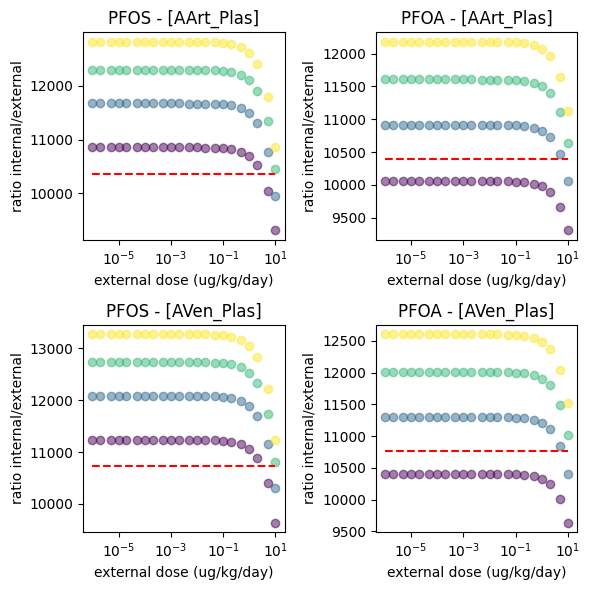

In [24]:
plot_internal_vs_external(param_simulation_results, selected_outputs, as_ratios=True)